# 01 — Exploración do subcorpus de Copyright

Análise detallada dos 656 documentos identificados como dereito de autor no corpus EUR-Lex. Obxectivo: decidir que tipos de documento (forms) e que filtros de lonxitude aplicar para o subcorpus experimental.

In [15]:
import json
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'

CORPUS  = Path('..') / 'data' / '02_intermediate' / 'corpus_clean.jsonl'
FIGURES = Path('..') / 'data' / '08_reporting' / 'eda' / 'figures'
TABLES  = Path('..') / 'data' / '08_reporting' / 'eda' / 'tables'

FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)

FAMILY_COLORS = {
    'LEGISLATIVE': '#4C72B0',
    'JUDICIAL':    '#DD8452',
    'POLICY':      '#55A868',
    'OTHER':       '#C44E52',
}

COPYRIGHT_KW = ['copyright', 'related right', 'neighbouring right', 'computer program', 'software']

records = []
with open(CORPUS, encoding='utf-8') as f:
    for line in f:
        doc = json.loads(line)
        if any(k in doc['title'].lower() for k in COPYRIGHT_KW):
            records.append(doc)

df = pd.DataFrame(records)
df['word_count'] = df['text'].str.split().str.len()
df['year'] = df['date'].apply(lambda d: int(d[6:10]) if d and len(d) >= 10 else None)

FAMILIES = ['JUDICIAL', 'LEGISLATIVE', 'POLICY', 'OTHER']
print(f'Total documentos copyright: {len(df):,}')
df[['family','form','word_count','year']].head(3)

Total documentos copyright: 656


,family,form,word_count,year
0,LEGISLATIVE,Directive,3253,2006
1,LEGISLATIVE,Directive,8261,2001
2,LEGISLATIVE,Directive,4599,2017


## 1. Visión xeral: familia e form

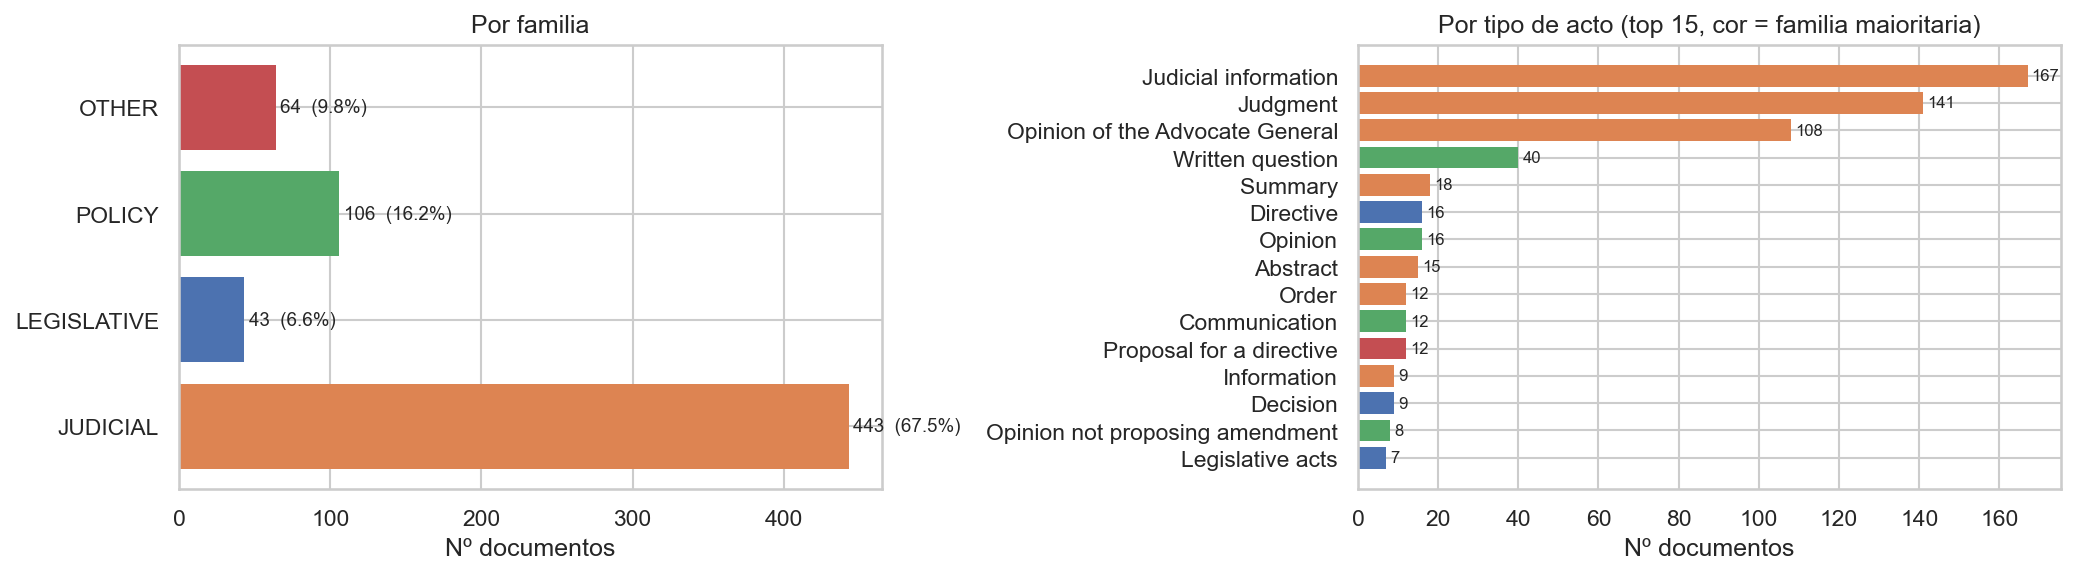

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Familia
ax = axes[0]
fam_counts = df['family'].value_counts().reindex(FAMILIES).dropna()
bars = ax.barh(fam_counts.index, fam_counts.values,
               color=[FAMILY_COLORS[f] for f in fam_counts.index], edgecolor='none')
for bar, val in zip(bars, fam_counts.values):
    ax.text(val + 3, bar.get_y() + bar.get_height()/2,
            f'{val}  ({val/len(df)*100:.1f}%)', va='center', fontsize=9)
ax.set_xlabel('Nº documentos')
ax.set_title('Por familia')

# Form (top 15)
ax2 = axes[1]
form_counts = df['form'].value_counts().head(15).sort_values()
colors = [FAMILY_COLORS[df[df['form']==f]['family'].mode()[0]] for f in form_counts.index]
ax2.barh(form_counts.index, form_counts.values, color=colors, edgecolor='none')
for i, (form, val) in enumerate(form_counts.items()):
    ax2.text(val + 1, i, str(val), va='center', fontsize=8)
ax2.set_xlabel('Nº documentos')
ax2.set_title('Por tipo de acto (top 15, cor = familia maioritaria)')

plt.tight_layout()
plt.savefig(FIGURES / 'copyright_overview.pdf')
plt.savefig(FIGURES / 'copyright_overview.png')
plt.show()

## 2. Lonxitude por form

Clave para decidir que forms conservar e se aplicar límite mínimo de palabras.

In [17]:
# Estatísticas de lonxitude por form (só forms con ≥3 docs)
length_stats = (
    df[df['word_count'] > 0]
    .groupby('form')['word_count']
    .agg(n='count', mediana='median', media='mean', p10=lambda x: x.quantile(0.1), p90=lambda x: x.quantile(0.9))
    .query('n >= 3')
    .sort_values('mediana', ascending=False)
    .astype({'n': int, 'mediana': int, 'media': int, 'p10': int, 'p90': int})
)
# Engadir familia maioritaria
length_stats['familia'] = length_stats.index.map(
    lambda f: df[df['form']==f]['family'].mode()[0] if len(df[df['form']==f]) > 0 else ''
)
display(length_stats)
length_stats.to_csv(TABLES / 'copyright_length_by_form.csv')


,n,mediana,media,p10,p90,familia
form,,,,,,
Impact assessment,3,88228,96705,19706,177095,POLICY
Proposal for a directive,12,9746,9707,3728,18497,OTHER
Opinion of the Advocate General,108,8603,10385,5282,18103,JUDICIAL
Amended proposal for a directive,4,7265,6669,4308,8554,OTHER
Information note,5,7184,13416,4647,25084,POLICY
Proposal for an act,4,6940,8122,4978,12211,POLICY
Legislative acts,7,6431,10326,3105,23941,LEGISLATIVE
Proposal for a decision without addressee,6,6144,5310,3374,6412,OTHER
Abstract,15,4104,5542,1282,9892,JUDICIAL


C:\Users\roica\AppData\Local\Temp\ipykernel_20932\1267609790.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, y='form', x=np.log10(plot_df['word_count']+1),


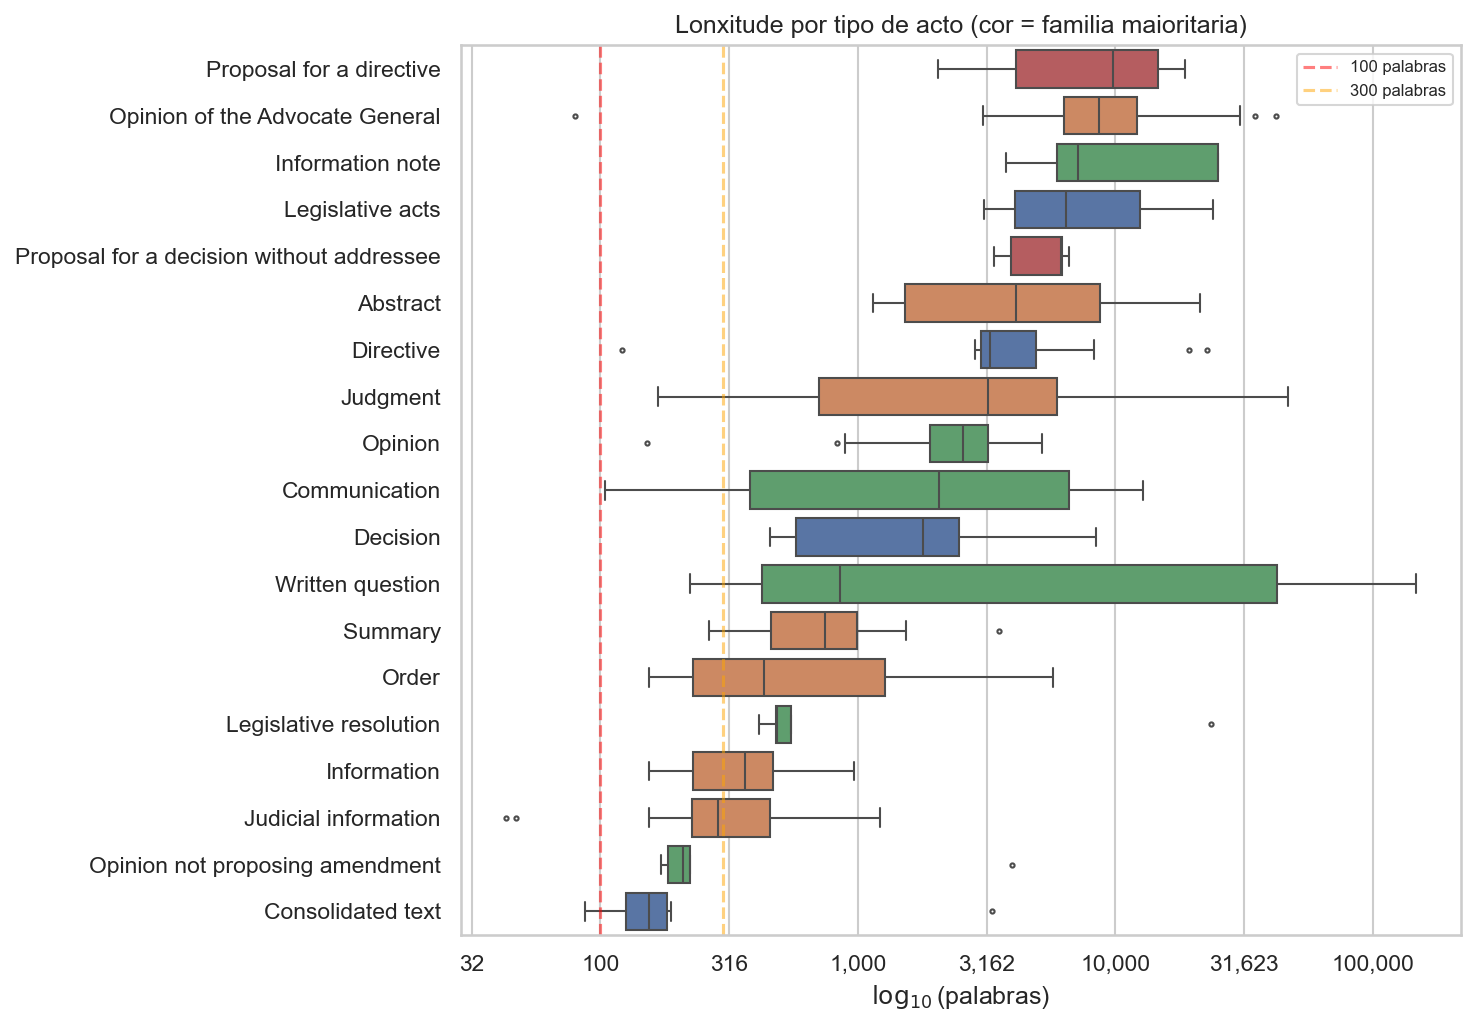

In [18]:
# Boxplot de lonxitude por form (só forms con ≥5 docs)
top_forms = df['form'].value_counts()[df['form'].value_counts() >= 5].index.tolist()
plot_df = df[df['form'].isin(top_forms) & (df['word_count'] > 0)].copy()
order = plot_df.groupby('form')['word_count'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10, 7))
form_colors = [FAMILY_COLORS[df[df['form']==f]['family'].mode()[0]] for f in order]
sns.boxplot(data=plot_df, y='form', x=np.log10(plot_df['word_count']+1),
            order=order, palette=form_colors, legend=False, fliersize=2, ax=ax)
ax.set_xlabel(r'$\log_{10}$(palabras)')
ax.set_ylabel('')
ax.set_title('Lonxitude por tipo de acto (cor = familia maioritaria)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{10**x:,.0f}'))
ax.axvline(np.log10(100), color='red', linestyle='--', alpha=0.5, label='100 palabras')
ax.axvline(np.log10(300), color='orange', linestyle='--', alpha=0.5, label='300 palabras')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / 'copyright_length_by_form.pdf')
plt.savefig(FIGURES / 'copyright_length_by_form.png')
plt.show()

## 3. Mostras de texto por form

Exemplos reais para xulgar a calidade do contido de cada tipo de acto.

In [19]:
SHOW_FORMS = [
    # Kept from before
    'Judgment', 'Opinion of the Advocate General', 'Judicial information',
    'Directive', 'Consolidated text',
    'Communication', 'Written question', 'Impact assessment', 'Green Paper',
    'Proposal for a directive',
    # Newly inspected
    'Abstract', 'Legislative acts', 'Amended proposal for a directive',
    'Proposal for an act', 'Information note', 'Proposal for a decision without addressee',
]
PREVIEW = 400  # caracteres

for form in SHOW_FORMS:
    sub = df[df['form'] == form]
    if sub.empty:
        continue
    row = sub.sample(1, random_state=42).iloc[0]
    print(f"{'='*65}")
    print(f"FORM    : {form}  (n={len(sub)})")
    print(f"Familia : {row['family']}")
    print(f"Título  : {row['title'][:90]}")
    print(f"Palabras: {row['word_count']:,}")
    print(f"Data    : {row['date']}")
    print(f"Texto   : {row['text'][:PREVIEW]}...")
    print()

FORM    : Judgment  (n=141)
Familia : JUDICIAL
Título  : Judgment of the Court (Fourth Chamber), 13 February 2014.Nils Svensson and Others v Retrie
Palabras: 3,752
Data    : 13/02/2014
Texto   : JUDGMENT OF THE COURT (Fourth Chamber)

13 February 2014 (
\*1
)

‛Reference for a preliminary ruling — Approximation of laws — Copyright and related rights — Directive 2001/29/EC — Information society — Harmonisation of certain aspects of copyright and related rights — Article 3(1) — Communication to the public — Meaning — Internet links (‘clickable links’) giving access to protected works’

In C...

FORM    : Opinion of the Advocate General  (n=108)
Familia : JUDICIAL
Título  : Opinion of Advocate General Sharpston delivered on 14 November 2013.OSA — Ochranný svaz au
Palabras: 8,592
Data    : 14/11/2013
Texto   : OPINION OF ADVOCATE GENERAL

SHARPSTON

delivered on 14 November 2013 (
1
)

Case C‑351/12

Ochranný svaz autorský pro práva k dílům hudebním, o.s. (OSA)

v

Léčebné lázně Mariánské 

## 4. Simulación de filtros

Cantos documentos quedan segundo diferentes combinacións de forms e límite mínimo de palabras.

### Criterio de seleccion de forms

A partires da inspeccion de lonxitudes (seccion 2) e das mostras de texto reais (seccion 3) estableceuse un **allowlist** de tipos de documento (forms) a conservar no corpus experimental. O criterio xeral foi: conservar so formas que contexan texto xuridico substantivo; excluir formas que sexan resumos, metadatos ou documentos de escasa lonxitude.

**Forms conservadas e xustificacion:**

| Categoria | Forms | Motivo |
|---|---|---|
| Xurisdicional | `Judgment`, `Opinion of the Advocate General`, `Order`, `Abstract` | Sentencias completas e opinions do Avogado Xeral. `Abstract` ten mediana de 4k-21k palabras; o nome e enganoso, son textos xudiciais completos |
| Lexislativo - actos | `Directive`, `Decision`, `Regulation`, `Consolidated text`, `Legislative acts` | Textos normativos en vigor. `Legislative acts` inclue a Directiva DSM 2019/790 completa (23k palabras) |
| Lexislativo - propostas | `Proposal for a directive`, `Amended proposal for a directive`, `Proposal for a regulation`, `Proposal for an act`, `Proposal for a decision without addressee` | Propostas lexislativas substantivas (6k-10k palabras de mediana). `Amended proposal for a directive` e o mesmo tipo que `Proposal for a directive` e non havia razon para excluila |
| Politica | `Communication`, `Impact assessment`, `Green Paper`, `Opinion`, `Information note`, `Written question` | Documentos de politica da Comision/Consello con contido analitico real. `Information note` son documentos do Consello sobre a tramitacion de directivas (ata 25k palabras) |

**Forms excluidas e xustificacion:**

| Form | n | Mediana | Motivo da exclusion |
|---|---|---|---|
| `Judicial information` | 167 | 285 pal. | Resumos curtos de sentencias (non o texto completo); a sentencia real esta como `Judgment` |
| `Summary` | 18 | 746 pal. | Resumos derivados doutros documentos |
| `Information` | 9 | 363 pal. | Textos moi curtos sen contido substantivo |
| `Opinion not proposing amendment` | 8 | 208 pal. | Os documentos mais curtos do corpus |
| `Legislative resolution` | 5 | 484 pal. | Resolucions formais breves |
| Formas con n=1-2 | varios | variable | Demasiado escasas; requeririan inspeccion individual sen impacto apreciable no corpus |



In [20]:
# Forms claramente substantivos (proposta: conservar)
FORMS_KEEP = {
    # Judicial
    'Judgment', 'Opinion of the Advocate General', 'Order', 'Abstract',
    # Legislative
    'Directive', 'Consolidated text', 'Decision', 'Regulation',
    'Legislative acts',
    # Proposals
    'Proposal for a directive', 'Amended proposal for a directive',
    'Proposal for a regulation', 'Proposal for an act',
    'Proposal for a decision without addressee',
    # Policy
    'Communication', 'Impact assessment', 'Green Paper', 'Opinion',
    'Information note', 'Written question',
}

# Simular combinacións
scenarios = [
    ('Sen filtro',                     df,                                                    None),
    ('Form allowlist',                 df[df['form'].isin(FORMS_KEEP)],                       None),
    ('Form + min 100 pal.',            df[df['form'].isin(FORMS_KEEP)],                        100),
    ('Form + min 200 pal.',            df[df['form'].isin(FORMS_KEEP)],                        200),
    ('Form + min 300 pal.',            df[df['form'].isin(FORMS_KEEP)],                        300),
    ('Form + min 300 + max 20k pal.',  df[df['form'].isin(FORMS_KEEP)],              (300, 20_000)),
]

rows = []
for label, sub, length in scenarios:
    if length is None:
        filtered = sub
    elif isinstance(length, tuple):
        filtered = sub[sub["word_count"].between(length[0], length[1])]
    else:
        filtered = sub[sub["word_count"] >= length]
    fam_counts = filtered["family"].value_counts().reindex(FAMILIES, fill_value=0)
    rows.append({"escenario": label, "total": len(filtered), **fam_counts.to_dict()})

sim_df = pd.DataFrame(rows)
display(sim_df)
sim_df.to_csv(TABLES / 'copyright_filter_scenarios.csv', index=False)

,escenario,total,JUDICIAL,LEGISLATIVE,POLICY,OTHER
0,Sen filtro,656,443,43,106,64
1,Form allowlist,421,278,34,80,29
2,Form + min 100 pal.,415,277,33,76,29
3,Form + min 200 pal.,401,272,29,71,29
4,Form + min 300 pal.,385,258,29,69,29
5,Form + min 300 + max 20k pal.,348,245,28,46,29


## 5. Distribución temporal

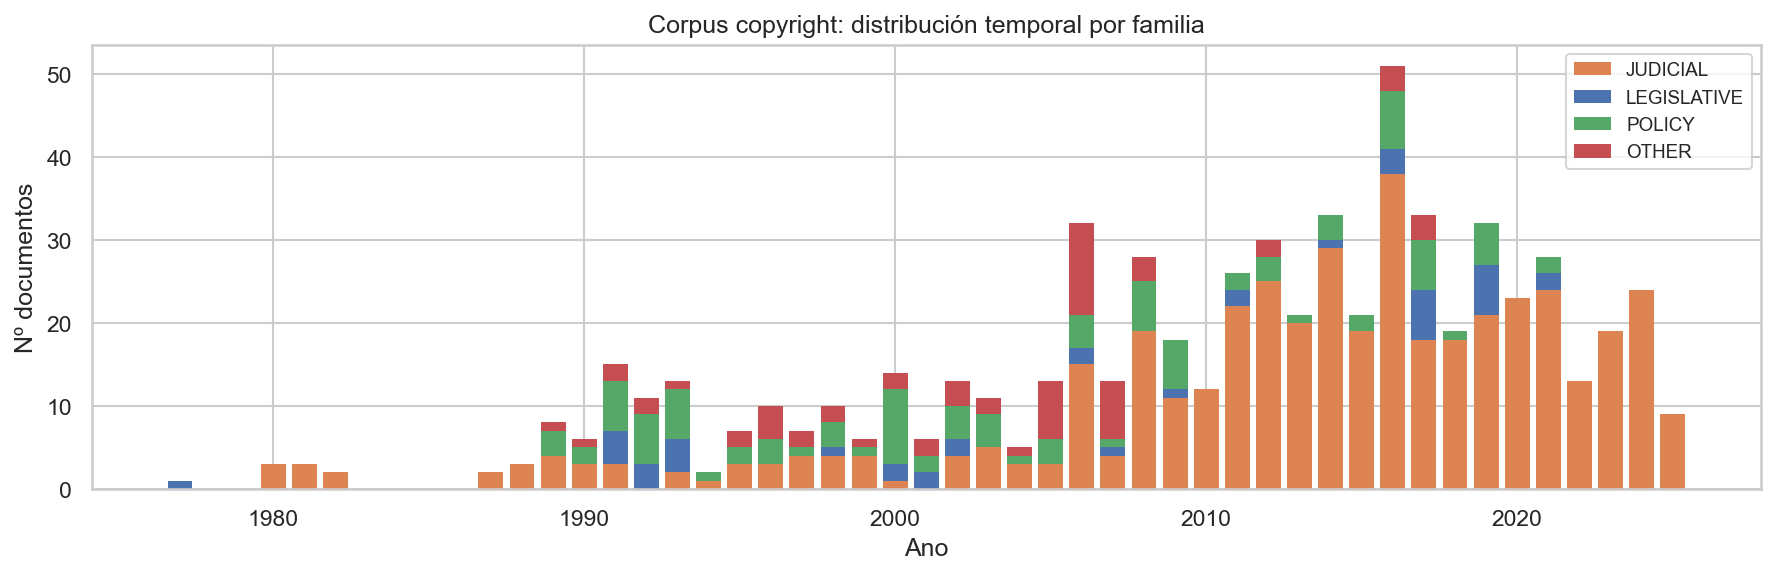

In [21]:
year_fam = df[df['year'].notna()].copy()
year_fam['year'] = year_fam['year'].astype(int)

pivot = year_fam.groupby(['year','family']).size().unstack(fill_value=0).reindex(columns=FAMILIES, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
bottom = pd.Series([0]*len(pivot), index=pivot.index)
for fam in FAMILIES:
    ax.bar(pivot.index, pivot[fam], bottom=bottom, color=FAMILY_COLORS[fam],
           label=fam, edgecolor='none', width=0.8)
    bottom += pivot[fam]
ax.set_xlabel('Ano')
ax.set_ylabel('Nº documentos')
ax.set_title('Corpus copyright: distribución temporal por familia')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'copyright_temporal.pdf')
plt.savefig(FIGURES / 'copyright_temporal.png')
plt.show()

### Filtro escollido: Form allowlist + minimo 300 palabras

Despois de inspeccionar o contido real dos documentos nos rangos de lonxitude baixa, estableceuse un **umbral minimo de 300 palabras** combinado co allowlist de forms.

**Documentos eliminados por estar baixo o umbral (36 en total, de 421 a 385):**

- **<100 palabras:** 4 con texto baleiro (fallo de extraccion), 1 Opinion of the Advocate General que e so unha referencia ao texto real, 1 Consolidated text con so a cabeceira de metadatos.
- **100-200 palabras:** Case todos metadatos ou cabeceiras sen o articulado real (Consolidated text), corrixendos tipograficos (Directive), e 3 Communications sobre actualizacions administrativas da lista de autoridades de monedas euro - sen analise xuridico substantivo.
- **200-300 palabras:** Maioritariamente syllabus/encabezados de sentenzas de incumprimento (Commission v. Member State) nos que o texto extraido e a lista de principios xuridicos sen o razoamento completo, o que os asimila funcionalmente aos `Judicial information` excluidos.

**Corpus final:** 385 documentos (258 JUDICIAL, 29 LEGISLATIVE, 69 POLICY, 29 OTHER).

